# **AudioSet (HuggingFace)**

**Fuente:** https://huggingface.co/datasets/agkphysics/AudioSet  

Se trata de la versión completa de AudioSet, accesible a través de HuggingFace. Lo usamos para complementar las clases subrepresentadas en el dataset de Zenodo, especialmente las categorías de emergencia (`siren`, `gunshot`, `alarm`).

- **Objetivo:** Explorar la distribución de las clases, la duración de los audios y la relevancia de las categorías de emergencia (`siren`, `gunshot`, `alarm`, etc.) para el sistema de alertas.
- AudioSet es un dataset muy grande (~2M clips). Usaremos **streaming** y **muestreo** para el EDA sin descargar todo el dataset.

## **1. Importaciones y configuración**

In [1]:
# Instalar dependencias necesarias
%pip install librosa soundfile kaggle seaborn scikit-learn datasets huggingface_hub pandas numpy matplotlib seaborn tqdm -q

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import seaborn as sns
import zipfile
import warnings
warnings.filterwarnings('ignore')

from huggingface_hub import dataset_info
from pathlib import Path
from tqdm.notebook import tqdm
from datasets import load_dataset, get_dataset_config_names
from collections import Counter

print('Librerías cargadas.')

Librerías cargadas.


In [3]:
# Configuración de estilo
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

# Clases de emergencia de interés para nuestro sistema de alertas
EMERGENCY_KEYWORDS = [
    'siren', 'alarm', 'gunshot', 'gun', 'explosion', 'fire',
    'smoke', 'emergency', 'ambulance', 'police', 'horn',
    'scream', 'shout', 'crash', 'breaking', 'glass'
]

## **2. Explorar configuraciones disponibles del dataset**

In [4]:
# Ver splits y configuraciones disponibles
try:
    configs = get_dataset_config_names('agkphysics/AudioSet')
    print('Configuraciones disponibles:', configs)
except Exception as e:
    print(f'No se pudieron obtener configs: {e}')
    print('Usando configuraciones por defecto: unbalanced_train')

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Configuraciones disponibles: ['balanced', 'unbalanced', 'full']


In [5]:
# Cargar información del dataset sin descargar datos
try:
    info = dataset_info('agkphysics/AudioSet')
    print(f'Dataset: {info.id}')
    print(f'Última modificación: {info.last_modified}')
    if info.card_data:
        print(f'Tags: {info.card_data.get("tags", "N/A")}')
except Exception as e:
    print(f'La información no está disponible: {e}')

Dataset: agkphysics/AudioSet
Última modificación: 2025-10-16 11:21:24+00:00
Tags: ['audio']


## **3. Carga en modo streaming (sin descargar todo el dataset)**

In [6]:
print('Cargando split de evaluación en modo streaming...')
ds_eval = load_dataset(
    'agkphysics/AudioSet',
    'balanced', # Usamos la configuración 'balanced' ya que 'eval' no existe
    split='test', # Especificamos el split 'test' ya que 'validation' no está disponible
    streaming=True
)

print('Dataset cargado en modo streaming')
print('Splits disponibles:', list(ds_eval.keys()) if hasattr(ds_eval, 'keys') else 'N/A')

Cargando split de evaluación en modo streaming...


Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/38 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/35 [00:00<?, ?it/s]

Dataset cargado en modo streaming
Splits disponibles: N/A


In [7]:
# Ver la estructura de un ejemplo
# Cuando se carga en modo streaming con un solo split, ds_eval ya es el IterableDataset

for example in ds_eval.take(1):
    print('Estructura de un ejemplo:')
    print('Columnas:', list(example.keys()))
    print()
    for k, v in example.items():
        if k == 'audio':
            print(f'- {k}: {{array shape: {np.array(v["array"]).shape}, sampling_rate: {v["sampling_rate"]}}}')
        elif isinstance(v, (list, np.ndarray)) and len(str(v)) > 100:
            print(f'- {k}: {type(v).__name__} de longitud {len(v)}')
        else:
            print(f'- {k}: {v}')

Estructura de un ejemplo:
Columnas: ['video_id', 'audio', 'labels', 'human_labels']

- video_id: -1PZQg5Gi8A
- audio: {array shape: (480000,), sampling_rate: 48000}
- labels: ['/m/07pjjrj']
- human_labels: ['Smash, crash']


## **4. Muestreo del dataset para el EDA**
- Tomamos una muestra representativa para el análisis (ajustamos `N_SAMPLES` según nuestra RAM).

In [8]:
N_SAMPLES = 5000 # Ajustamos según nuestra RAM: 2000 (4GB), 5000 (8GB), 10000 (16GB+)

records = []
print(f'Muestreando {N_SAMPLES} ejemplos del split eval...')

for i, example in enumerate(tqdm(ds_eval.take(N_SAMPLES), total=N_SAMPLES)):
    record = {}
    for k, v in example.items():
        if k == 'audio':
            arr = np.array(v['array'])
            record['duration_seconds'] = len(arr) / v['sampling_rate']
            record['sampling_rate'] = v['sampling_rate']
            record['audio_length_samples'] = len(arr)
        elif k in ('human_labels', 'labels', 'label', 'tags'):
            # Normalizar el campo de etiquetas (puede variar según la versión)
            record['labels'] = v if isinstance(v, list) else [v]
        else:
            record[k] = v
    records.append(record)

df = pd.DataFrame(records)
print(f'\nDataFrame creado: {df.shape[0]} filas × {df.shape[1]} columnas')

Muestreando 5000 ejemplos del split eval...


  0%|          | 0/5000 [00:00<?, ?it/s]


DataFrame creado: 5000 filas × 5 columnas


## **5. Inspección básica del DataFrame**

In [9]:
df.head(10)

,video_id,duration_seconds,sampling_rate,audio_length_samples,labels
0,-1PZQg5Gi8A,10.000000,48000,480000,"[Smash, crash]"
1,-1Hub6Ps_cc,10.000000,48000,480000,"[Sink (filling or washing), Water tap, faucet,..."
2,-1nilez17Dg,10.000000,44100,441000,"[Heart murmur, Speech]"
3,-1OlgJWehn8,10.000000,44100,441000,"[Music, Radio]"
4,-1LQP2wemiQ,10.000000,48000,480000,"[Beep, bleep, Female speech, woman speaking, S..."
5,-1hDIl9Udkw,10.000000,44100,441000,"[Music, Rattle, Speech]"
6,-21_SXelVNo,10.000000,48000,480000,"[Sniff, Speech]"
7,-1pRmoJIGQc,10.000023,44100,441001,"[Engine knocking, Engine, Idling]"
8,-22tna7KHzI,9.433500,48000,452808,[Explosion]
9,-2EKWgTNEYU,10.000000,48000,480000,[Radio]


In [10]:
df.tail(10)

,video_id,duration_seconds,sampling_rate,audio_length_samples,labels
4990,BaMThaDkWk4,10.0,44100,441000,"[Singing, Gospel music, Music, Vocal music, A ..."
4991,Baeh17Bzpcc,10.0,48000,480000,[Crunch]
4992,BbNHWQrTu2o,10.0,48000,480000,[Waterfall]
4993,Batuxqz85WA,10.0,48000,480000,"[Music, Neigh, whinny]"
4994,BbWdsbZ9TsM,10.0,48000,480000,"[Subway, metro, underground, Railroad car, tra..."
4995,BbOVvWpZAWo,10.0,44100,441000,"[Slam, Speech, Outside, urban or manmade]"
4996,BbVoVbQHoXo,10.0,48000,480000,[Typewriter]
4997,Bc5DjcRfCZ8,10.0,48000,480000,[Crunch]
4998,BbedVdUH4LA,10.0,48000,480000,"[Boat, Water vehicle, Wind, Rowboat, canoe, ka..."
4999,Bcrh-fR3XJk,10.0,44100,441000,"[Buzz, Speech]"


In [11]:
df.columns

Index(['video_id', 'duration_seconds', 'sampling_rate', 'audio_length_samples',
       'labels'],
      dtype='object')

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   video_id              5000 non-null   object 
 1   duration_seconds      5000 non-null   float64
 2   sampling_rate         5000 non-null   int64  
 3   audio_length_samples  5000 non-null   int64  
 4   labels                5000 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 195.4+ KB


In [13]:
df.describe()

,duration_seconds,sampling_rate,audio_length_samples
count,5000.000000,5000.000000,5000.000000
mean,9.896800,47684.880000,471929.910600
std,0.601527,1062.964423,30633.801882
min,0.993500,44100.000000,47688.000000
25%,10.000000,48000.000000,480000.000000
50%,10.000000,48000.000000,480000.000000
75%,10.000000,48000.000000,480000.000000
max,10.000794,48000.000000,480000.000000


In [14]:
print("Valores nulos")
df.isnull().sum()

Valores nulos


,0
video_id,0
duration_seconds,0
sampling_rate,0
audio_length_samples,0
labels,0


In [15]:
print("Valores faltantes del dataframe")
df.isna().sum().sum()

Valores faltantes del dataframe


np.int64(0)

In [16]:
print("Valores faltantes para cada columna")
df.isna().sum()

Valores faltantes para cada columna


,0
video_id,0
duration_seconds,0
sampling_rate,0
audio_length_samples,0
labels,0


In [17]:
(df.isna().sum() / len(df) * 100).sort_values(ascending=False)

,0
video_id,0.0
duration_seconds,0.0
sampling_rate,0.0
audio_length_samples,0.0
labels,0.0


In [18]:
print("Tipos de datos")
df.dtypes

Tipos de datos


,0
video_id,object
duration_seconds,float64
sampling_rate,int64
audio_length_samples,int64
labels,object


In [19]:
print("Posibles variables categóricas")
df.select_dtypes(include=['object']).columns

Posibles variables categóricas


Index(['video_id', 'labels'], dtype='object')

In [20]:
print("Columnas de etiquetas")
label_col = 'labels' if 'labels' in df.columns else 'human_labels'
print(f'Columna de etiquetas detectada: "{label_col}"')
print('Ejemplo de etiquetas:', df[label_col].iloc[0] if label_col in df.columns else 'No se encontró.')

Columnas de etiquetas
Columna de etiquetas detectada: "labels"
Ejemplo de etiquetas: ['Smash, crash']


## **6. Análisis de etiquetas (clases)**


In [21]:
# Aplanar todas las etiquetas (multi-label dataset)
if label_col in df.columns:
    all_labels = [label for sublist in df[label_col].dropna() for label in sublist]
    label_counts = Counter(all_labels)
    df_labels = pd.DataFrame(label_counts.items(), columns=['label', 'count']).sort_values('count', ascending=False)

    print(f'Total de etiquetas únicas: {len(label_counts)}')
    print(f'Promedio de etiquetas por clip: {sum(label_counts.values()) / len(df):.2f}')
    print()
    print('Top 20 etiquetas más frecuentes:')
    print(df_labels.head(20).to_string(index=False))

Total de etiquetas únicas: 527
Promedio de etiquetas por clip: 2.58

Top 20 etiquetas más frecuentes:
                    label  count
                    Music   1385
                   Speech   1285
                  Vehicle    213
                   Animal    205
       Inside, small room    127
       Musical instrument    107
   Domestic animals, pets    104
                  Singing     91
                   Guitar     88
Plucked string instrument     74
      Boat, Water vehicle     73
                    Water     73
                      Car     72
                     Fowl     66
                      Dog     64
                     Bird     62
           Rail transport     57
Railroad car, train wagon     56
                    Train     55
                   Engine     54


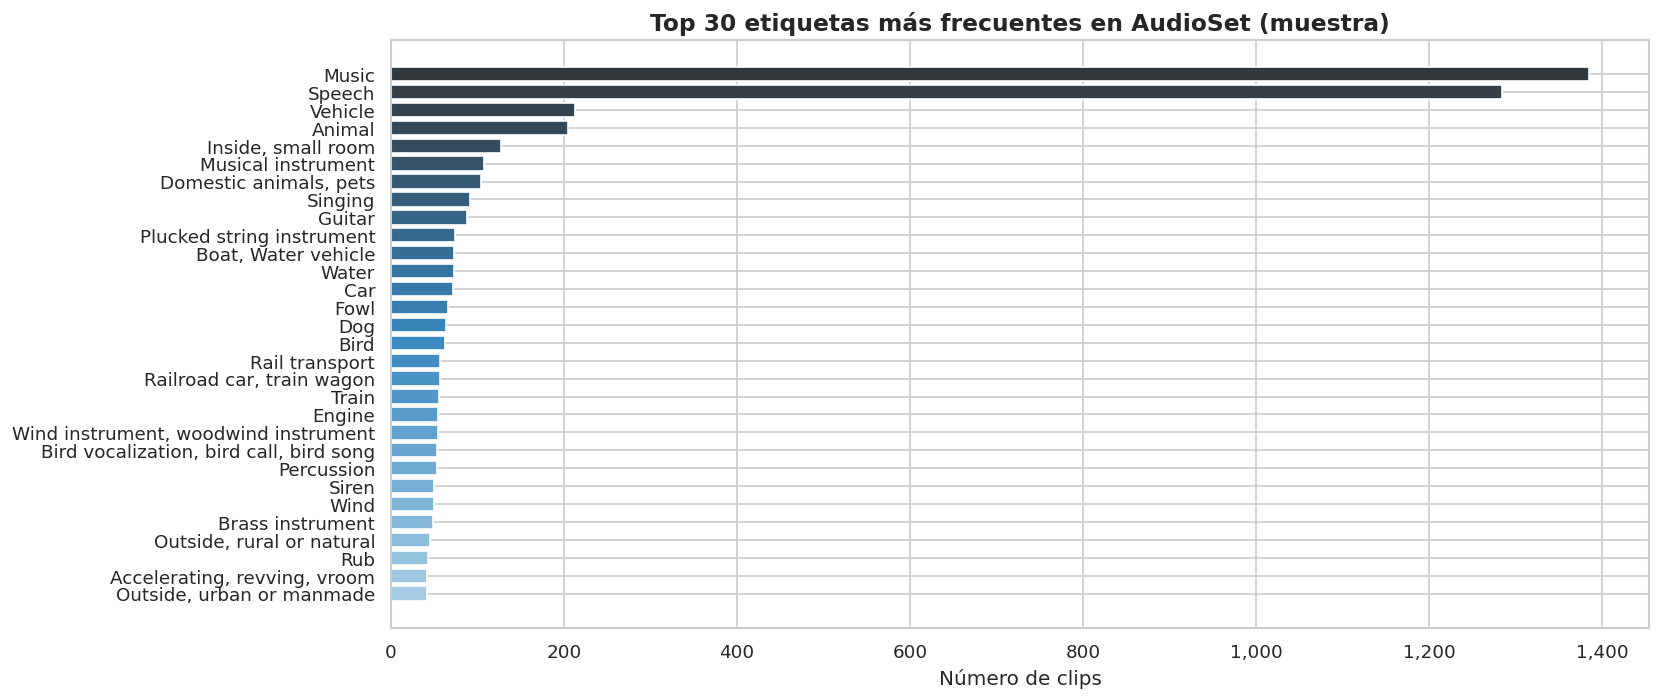

In [22]:
# Distribución de las 30 etiquetas más comunes
fig, ax = plt.subplots(figsize=(14, 6))
top30 = df_labels.head(30)
bars = ax.barh(top30['label'][::-1], top30['count'][::-1], color=sns.color_palette('Blues_d', 30))
ax.set_xlabel('Número de clips', fontsize=12)
ax.set_title('Top 30 etiquetas más frecuentes en AudioSet (muestra)', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## **7. Análisis de clases de EMERGENCIA (foco del proyecto)**

In [23]:
# Filtrar etiquetas relacionadas con emergencias
emergency_labels = {
    label: count
    for label, count in label_counts.items()
    if any(kw.lower() in label.lower() for kw in EMERGENCY_KEYWORDS)
}
df_emergency = pd.DataFrame(emergency_labels.items(), columns=['label', 'count']).sort_values('count', ascending=False)

print(f'Etiquetas de emergencia encontradas: {len(df_emergency)}')
print()
print(df_emergency.to_string(index=False))

Etiquetas de emergencia encontradas: 30

                          label  count
                          Siren     50
              Emergency vehicle     36
               Gunshot, gunfire     30
                     Train horn     24
Vehicle horn, car horn, honking     22
                    Alarm clock     20
           Air horn, truck horn     18
                          Shout     18
                           Fire     17
                          Glass     17
                        Foghorn     17
                       Breaking     17
                   Smash, crash     16
              Ambulance (siren)     16
             Police car (siren)     16
                      Car alarm     16
                          Alarm     16
Fire engine, fire truck (siren)     15
                      Explosion     15
    Smoke detector, smoke alarm     14
                    Machine gun     14
                    French horn     14
                     Fire alarm     13
            Civil defen

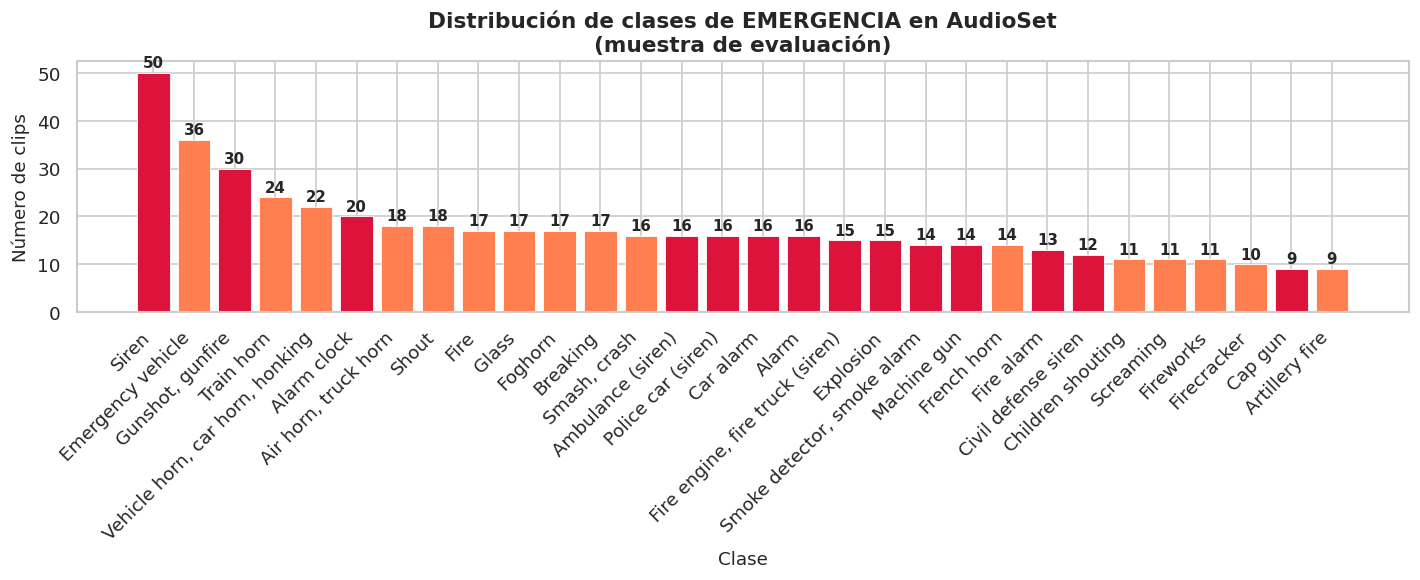

In [24]:
# Visualización de clases de emergencia
if not df_emergency.empty:
    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['crimson' if any(kw in l.lower() for kw in ['siren', 'alarm', 'gun', 'explo'])
              else 'coral' for l in df_emergency['label']]
    bars = ax.bar(df_emergency['label'], df_emergency['count'], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xlabel('Clase', fontsize=11)
    ax.set_ylabel('Número de clips', fontsize=11)
    ax.set_title('Distribución de clases de EMERGENCIA en AudioSet\n(muestra de evaluación)', fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right')

    # Añadir valores encima de las barras
    for bar, val in zip(bars, df_emergency['count']):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

Clips con etiqueta de emergencia: 368 (7.36 %)
Clips sin etiqueta de emergencia: 4632 (92.64 %)


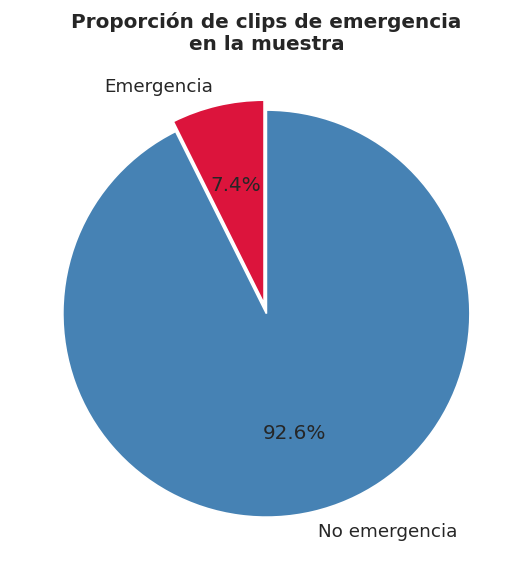

In [25]:
# Clips con al menos una etiqueta de emergencia
def has_emergency(labels):
    if not isinstance(labels, list):
        return False
    return any(any(kw.lower() in l.lower() for kw in EMERGENCY_KEYWORDS) for l in labels)

df['is_emergency'] = df[label_col].apply(has_emergency)
n_emergency = df['is_emergency'].sum()
pct_emergency = n_emergency / len(df) * 100

print(f'Clips con etiqueta de emergencia: {n_emergency} ({pct_emergency:.2f} %)')
print(f'Clips sin etiqueta de emergencia: {len(df) - n_emergency} ({100-pct_emergency:.2f} %)')

# Pie chart
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(
    [n_emergency, len(df) - n_emergency],
    labels=['Emergencia', 'No emergencia'],
    colors=['crimson', 'steelblue'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0)
)
ax.set_title('Proporción de clips de emergencia\nen la muestra', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## **8. Análisis de la duración de los clips**

In [26]:
if 'duration_seconds' in df.columns:
    print('Estadísticas de duración (segundos):')
    print(df['duration_seconds'].describe().round(3))
    print()
    print(f'Duración mínima: {df["duration_seconds"].min():.2f}s')
    print(f'Duración máxima: {df["duration_seconds"].max():.2f}s')
    print(f'Duración media: {df["duration_seconds"].mean():.2f}s')
    print(f'Duración mediana: {df["duration_seconds"].median():.2f}s')
    print(f'Clips de exactamente 10s: {(df["duration_seconds"].round(1) == 10.0).sum()}')

Estadísticas de duración (segundos):
count    5000.000
mean        9.897
std         0.602
min         0.994
25%        10.000
50%        10.000
75%        10.000
max        10.001
Name: duration_seconds, dtype: float64

Duración mínima: 0.99s
Duración máxima: 10.00s
Duración media: 9.90s
Duración mediana: 10.00s
Clips de exactamente 10s: 4617


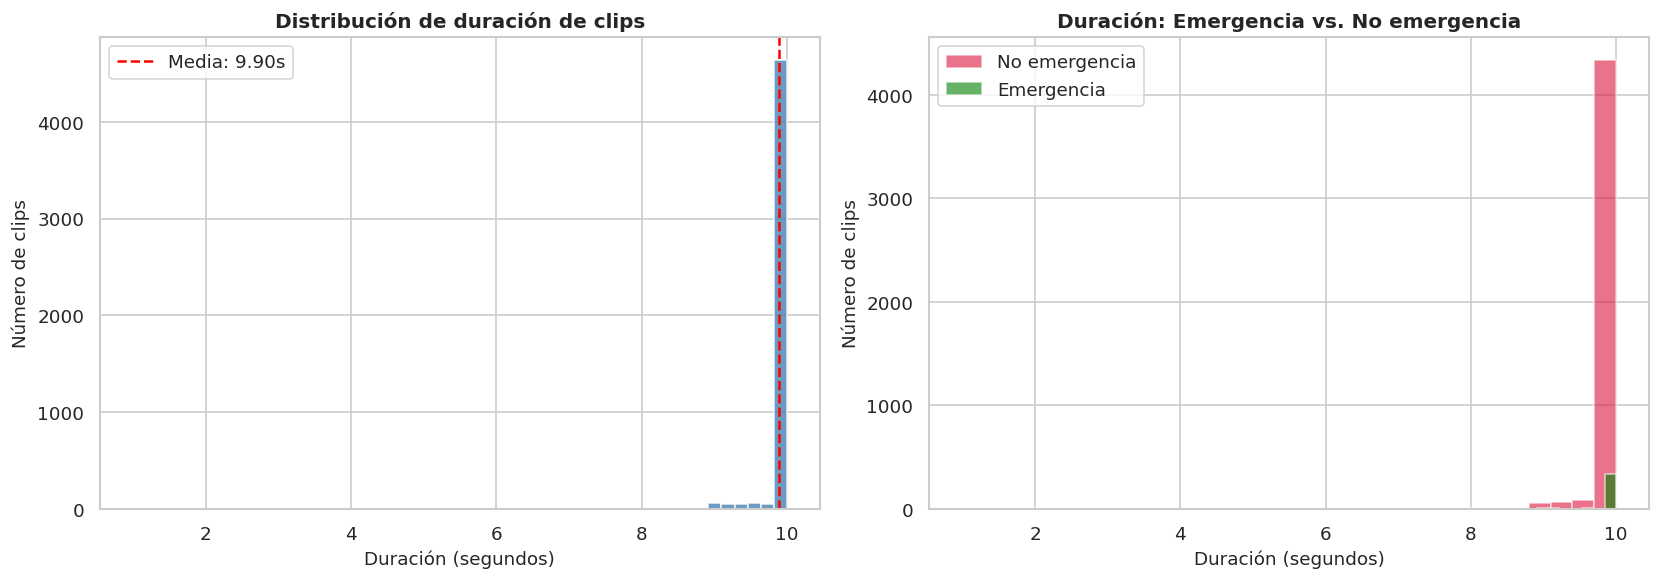

In [27]:
if 'duration_seconds' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Histograma general
    axes[0].hist(df['duration_seconds'], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0].set_xlabel('Duración (segundos)', fontsize=11)
    axes[0].set_ylabel('Número de clips', fontsize=11)
    axes[0].set_title('Distribución de duración de clips', fontsize=12, fontweight='bold')
    axes[0].axvline(df['duration_seconds'].mean(), color='red', linestyle='--', label=f'Media: {df["duration_seconds"].mean():.2f}s')
    axes[0].legend()

    # Duración por tipo: emergencia vs. no emergencia
    colors_map = {True: 'green', False: 'crimson'}
    for is_emerg, group in df.groupby('is_emergency'):
        label = 'Emergencia' if is_emerg else 'No emergencia'
        axes[1].hist(group['duration_seconds'], bins=30, alpha=0.6,
                     color=colors_map[is_emerg], label=label, edgecolor='white')
    axes[1].set_xlabel('Duración (segundos)', fontsize=11)
    axes[1].set_ylabel('Número de clips', fontsize=11)
    axes[1].set_title('Duración: Emergencia vs. No emergencia', fontsize=12, fontweight='bold')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## **9. Análisis de co-ocurrencia de etiquetas**

In [28]:
# Número de etiquetas por clip
df['n_labels'] = df[label_col].apply(lambda x: len(x) if isinstance(x, list) else 0)

print('Número de etiquetas por clip:')
print(df['n_labels'].describe().round(2))
print()
print('Distribución:')
print(df['n_labels'].value_counts().sort_index().head(15))

Número de etiquetas por clip:
count    5000.00
mean        2.58
std         1.44
min         1.00
25%         2.00
50%         2.00
75%         3.00
max        11.00
Name: n_labels, dtype: float64

Distribución:
n_labels
1     1157
2     1692
3     1116
4      538
5      257
6      144
7       54
8       30
9        8
10       3
11       1
Name: count, dtype: int64


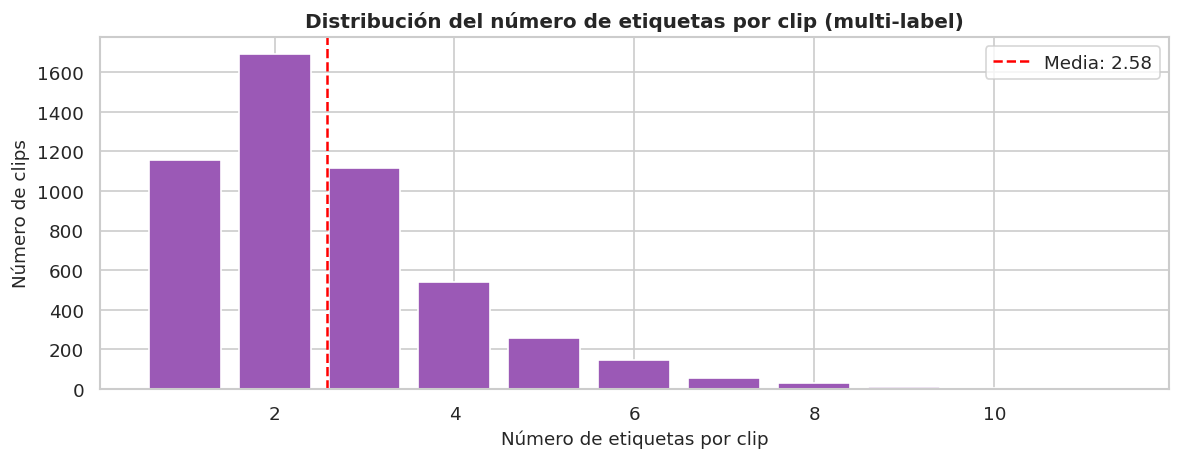

In [29]:
fig, ax = plt.subplots(figsize=(10, 4))
val_counts = df['n_labels'].value_counts().sort_index()
ax.bar(val_counts.index, val_counts.values, color='#9b59b6', edgecolor='white')
ax.set_xlabel('Número de etiquetas por clip', fontsize=11)
ax.set_ylabel('Número de clips', fontsize=11)
ax.set_title('Distribución del número de etiquetas por clip (multi-label)', fontsize=12, fontweight='bold')
ax.axvline(df['n_labels'].mean(), color='red', linestyle='--',
           label=f'Media: {df["n_labels"].mean():.2f}')
ax.legend()
plt.tight_layout()
plt.show()

## **10. Desbalance de clases (relevante para el modelo)**

In [30]:
# Ratio de desbalance: clase más frecuente vs. clases de emergencia
if not df_emergency.empty and not df_labels.empty:
    top_class_count = df_labels['count'].iloc[0]
    top_class_name = df_labels['label'].iloc[0]

    print('ANÁLISIS DE DESBALANCE DE CLASES')
    print('='*50)
    print(f'Clase más frecuente: "{top_class_name}" ({top_class_count} clips)')
    print()
    print('Ratio de desbalance (clase más frecuente / clase de emergencia):')
    print()
    max_ratio = max(top_class_count / row['count'] for _, row in df_emergency.iterrows() if row['count'] > 0)
    for _, row in df_emergency.iterrows():
        ratio = top_class_count / row['count'] if row['count'] > 0 else float('inf')
        bar_len = int((ratio / max_ratio) * 40)
        bar = '█' * bar_len
        print(f"- {row['label']:35s} | {row['count']:5d} clips | ratio: {ratio:.2f}x | {bar}")

ANÁLISIS DE DESBALANCE DE CLASES
Clase más frecuente: "Music" (1385 clips)

Ratio de desbalance (clase más frecuente / clase de emergencia):

- Siren                               |    50 clips | ratio: 27.70x | ███████
- Emergency vehicle                   |    36 clips | ratio: 38.47x | ██████████
- Gunshot, gunfire                    |    30 clips | ratio: 46.17x | ████████████
- Train horn                          |    24 clips | ratio: 57.71x | ███████████████
- Vehicle horn, car horn, honking     |    22 clips | ratio: 62.95x | ████████████████
- Alarm clock                         |    20 clips | ratio: 69.25x | ██████████████████
- Air horn, truck horn                |    18 clips | ratio: 76.94x | ████████████████████
- Shout                               |    18 clips | ratio: 76.94x | ████████████████████
- Fire                                |    17 clips | ratio: 81.47x | █████████████████████
- Glass                               |    17 clips | ratio: 81.47x | ██████████

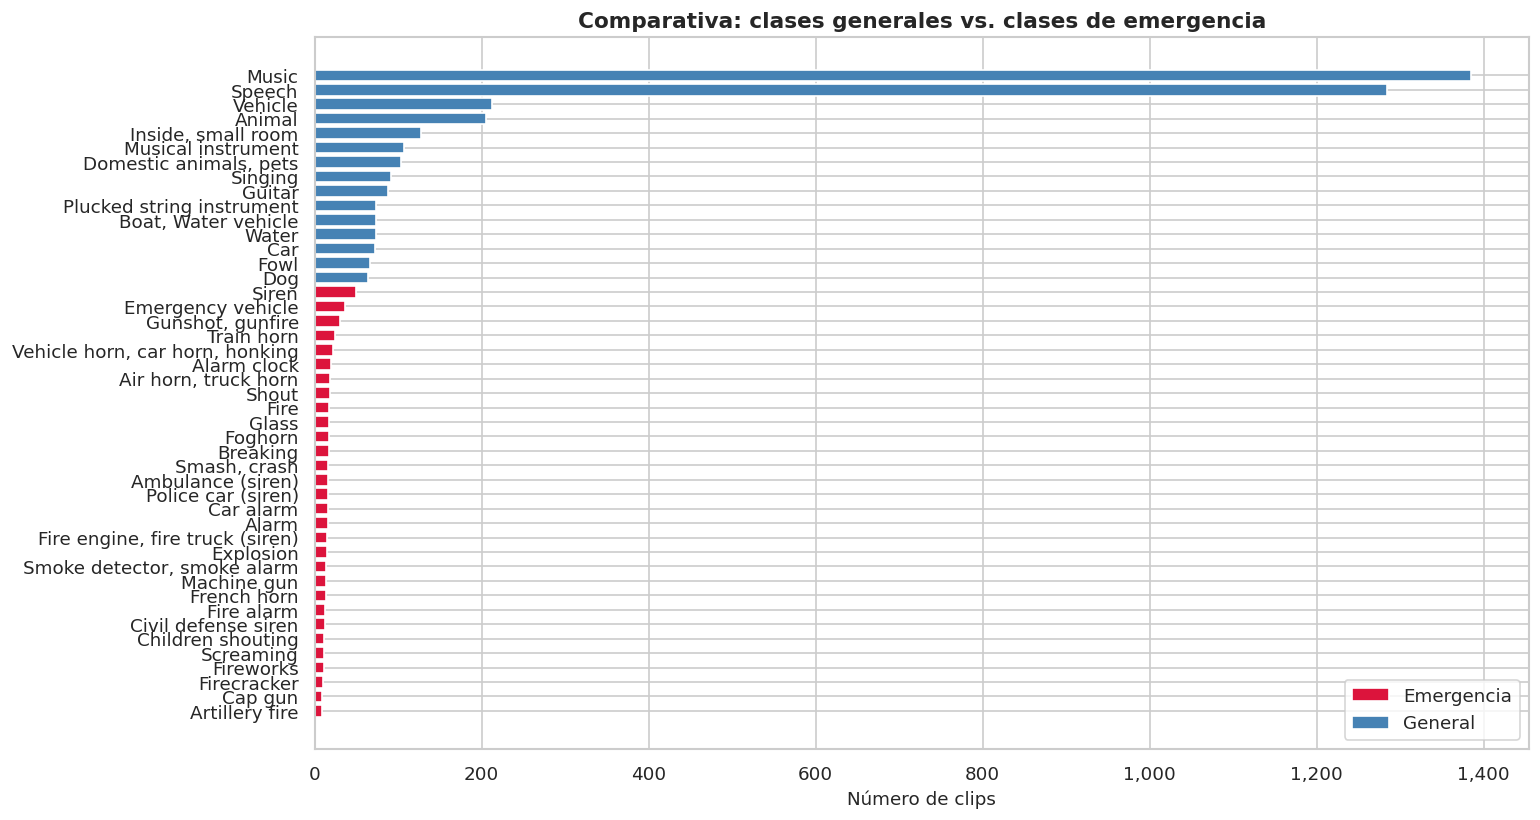

In [31]:
# Heatmap comparativo: top 15 generales vs. todas las de emergencia
top15 = list(df_labels['label'].head(15))
emerg_list = list(df_emergency['label'])
compare_labels = top15 + [l for l in emerg_list if l not in top15]
compare_counts = [label_counts.get(l, 0) for l in compare_labels]
is_emerg_flag = ['Emergencia' if l in emerg_list else 'General' for l in compare_labels]

df_compare = pd.DataFrame({
    'label': compare_labels,
    'count': compare_counts,
    'tipo': is_emerg_flag
}).sort_values('count', ascending=False)

fig, ax = plt.subplots(figsize=(13, 7))
color_map = {'Emergencia': 'crimson', 'General': 'steelblue'}
bar_colors = [color_map[t] for t in df_compare['tipo']]
bars = ax.barh(df_compare['label'][::-1], df_compare['count'][::-1],
               color=bar_colors[::-1], edgecolor='white')

# Leyenda manual
legend_elements = [Patch(facecolor='crimson', label='Emergencia'),
                   Patch(facecolor='steelblue', label='General')]
ax.legend(handles=legend_elements, loc='lower right')
ax.set_xlabel('Número de clips', fontsize=11)
ax.set_title('Comparativa: clases generales vs. clases de emergencia', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## **11. Sample Rate y compatibilidad de audio**

In [32]:
if 'sampling_rate' in df.columns:
    print('Sample rates encontrados:')
    print(df['sampling_rate'].value_counts())
    print()
    print('Todos los clips tienen el mismo sample rate:', df['sampling_rate'].nunique() == 1)
    print(f'Sample rate: {df["sampling_rate"].iloc[0]} Hz')
    print()
    target_sr = 16000 # común para modelos de audio
    needs_resample = (df['sampling_rate'] != target_sr).sum()
    print(f'Clips que necesitarían resampling a {target_sr}Hz: {needs_resample}')

Sample rates encontrados:
sampling_rate
48000    4596
44100     404
Name: count, dtype: int64

Todos los clips tienen el mismo sample rate: False
Sample rate: 48000 Hz

Clips que necesitarían resampling a 16000Hz: 5000


## **12. Resumen y conclusiones**

In [33]:
print('='*60)
print('RESUMEN DEL EDA: AUDIOSET')
print('='*60)
print()
print(f'Muestra analizada: {len(df):,} clips')
print(f'Clases únicas: {len(label_counts):,}')
print(f'Clases de emergencia: {len(df_emergency)}')
print(f'Clips con emergencia: {df["is_emergency"].sum():,} ({df["is_emergency"].mean()*100:.2f} %)')
if 'duration_seconds' in df.columns:
    print(f'Duración media: {df["duration_seconds"].mean():.2f}s')
    print(f'Duración más común: 10s (AudioSet estándar)')
print(f'Etiquetas/clip (media): {df["n_labels"].mean():.2f}')
if 'sampling_rate' in df.columns:
    print(f'Sample rate: {df["sampling_rate"].iloc[0]} Hz')
print()
print('DESAFÍOS IDENTIFICADOS:')
print('1. El dataset está muy desbalanceado: las clases de emergencia son minoría.')
print('2. Multi-label: un clip puede pertenecer a varias clases.')
print('3. Necesidad de oversampling/augmentation para clases de emergencia.')
print()
print('RECOMENDACIONES PARA EL MODELO:')
print('- Usar AudioSet como complemento del dataset principal (FDS50K).')
print('- Filtrar solo las clases de emergencia relevantes.')
print('- Aplicar data augmentation.')
print('- Considerar weighted loss para clases minoritarias.')
print('- Normalizar al mismo sample rate que el dataset principal.')
print()
print('Clases de emergencia encontradas:')
for _, row in df_emergency.iterrows():
    print(f'- {row["label"]}: {row["count"]} clips')

RESUMEN DEL EDA: AUDIOSET

Muestra analizada: 5,000 clips
Clases únicas: 527
Clases de emergencia: 30
Clips con emergencia: 368 (7.36 %)
Duración media: 9.90s
Duración más común: 10s (AudioSet estándar)
Etiquetas/clip (media): 2.58
Sample rate: 48000 Hz

DESAFÍOS IDENTIFICADOS:
1. El dataset está muy desbalanceado: las clases de emergencia son minoría.
2. Multi-label: un clip puede pertenecer a varias clases.
3. Necesidad de oversampling/augmentation para clases de emergencia.

RECOMENDACIONES PARA EL MODELO:
- Usar AudioSet como complemento del dataset principal (FDS50K).
- Filtrar solo las clases de emergencia relevantes.
- Aplicar data augmentation.
- Considerar weighted loss para clases minoritarias.
- Normalizar al mismo sample rate que el dataset principal.

Clases de emergencia encontradas:
- Siren: 50 clips
- Emergency vehicle: 36 clips
- Gunshot, gunfire: 30 clips
- Train horn: 24 clips
- Vehicle horn, car horn, honking: 22 clips
- Alarm clock: 20 clips
- Air horn, truck horn:

## **13. Guardar el DataFrame de muestra para uso posterior**

In [34]:
# Guardar muestra (sin el array de audio, solo metadatos)
df_meta = df.drop(columns=['audio'] if 'audio' in df.columns else [])

# Convertir listas a strings para el CSV
df_meta_csv = df_meta.copy()
if label_col in df_meta_csv.columns:
    df_meta_csv[label_col] = df_meta_csv[label_col].apply(
        lambda x: '|'.join(x) if isinstance(x, list) else str(x)
    )

df_meta_csv.to_csv('audioset_sample_metadata.csv', index=False)
print(f'Metadatos guardados en audioset_sample_metadata.csv ({df_meta_csv.shape[0]} filas)')

# Guardar también las clases de emergencia
df_emergency.to_csv('audioset_emergency_classes.csv', index=False)
print(f'Clases de emergencia guardadas en audioset_emergency_classes.csv')

Metadatos guardados en audioset_sample_metadata.csv (5000 filas)
Clases de emergencia guardadas en audioset_emergency_classes.csv
